# 16-QAM Multimode Block Mode Tutorial

This tutorial builds a compact 16-QAM transmitter using Block mode simulation. It is meant to follow the MZI lattice tutorial: the MZI tutorial explains S-parameter dictionaries, pole-residue fitting, and the single-mode Block mode workflow; this tutorial focuses on the pieces that were not emphasized there.

Here we cover:

- Multimode optical signals with shape `(time, wavelength, mode)`.
- SAX `SDict` keys with mode suffixes such as `o0@te` and `o1@tm`.
- Wrapping single-polarization SAX models into multimode models.
- A small MZI/IQ lattice that generates a 16-QAM-like constellation.
- Reading mode-resolved outputs from a `BlockModeSimulationResult`.


## 1. Imports

In [1]:
import os
import warnings
from functools import partial

os.environ.setdefault('JAX_PLATFORMS', 'cpu')
warnings.filterwarnings('ignore', message='Could not validate netlist.*')
warnings.filterwarnings('ignore', message='FigureCanvasAgg is non-interactive.*')

import jax
import jax.numpy as jnp
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, filtfilt

from simphony.circuit.circuit import Circuit
from simphony.component.component import BlockModeComponent
from simphony.component.port import Port
from simphony.libraries.siepic import waveguide, y_branch
from simphony.signal.block_mode import BlockModeOpticalSignal
from simphony.simulation.block_mode import BlockModeSimulation, BlockModeSimulationParameters
from simphony.utils import create_multimode_sax_model

## 2. Multimode Block Mode Signals

In Block mode, an optical signal is stored as a block of samples:

```text
amplitude.shape == (num_time_steps, num_wavelengths, num_modes)
```

The previous MZI lattice tutorial used one mode, so the last axis had length 1. Here we use two modes:

```text
mode_identifiers = ("te", "tm")
```

That means `amplitude[:, 0, 0]` is the TE envelope at the first baseband wavelength, and `amplitude[:, 0, 1]` is the TM envelope at that same baseband wavelength. The mode order comes from `BlockModeSimulationParameters.mode_identifiers`. Thus, users can interface their custom components with the different modes. 

In [2]:
MODE_IDENTIFIERS = ('te', 'tm')
BASEBAND_WAVELENGTHS_M = jnp.array([1.55e-6])
DT = 1e-14

mode_index = {mode: index for index, mode in enumerate(MODE_IDENTIFIERS)}
print('mode index:', mode_index)
print('baseband wavelength grid (nm):', np.asarray(BASEBAND_WAVELENGTHS_M) * 1e9)

mode index: {'te': 0, 'tm': 1}
baseband wavelength grid (nm): [1550.]


## 3. Generate the 16-QAM Drive Signal Using the Original Settings

This tutorial now uses the following drive settings:

- `N = 20000` random symbols.
- `sps = 25` samples per symbol.
- Phase levels `7π/8`, `1.80π/3`, `π/2.50`, and `π/8`.
- `smooth_hold(... cutoff=0.05, order=2)` using a Butterworth filter.
- Opposite phase waveforms on each MZI pair: `phase_wave2 = -phase_wave1` and `phase_wave4 = -phase_wave3`.

These phase levels are important because each MZI branch responds roughly through `cos(phase)`, so the selected phases produce four distinct amplitude levels for the 16-QAM grid.

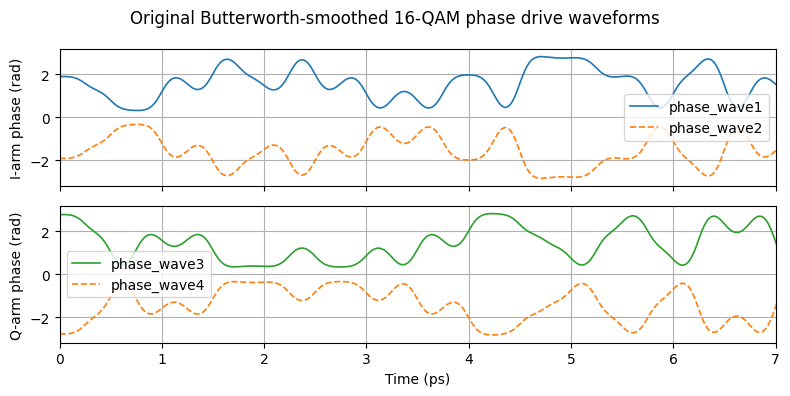

phase levels (rad): [2.749 1.885 1.257 0.393]
cosine amplitude levels: [-0.924 -0.309  0.309  0.924]
N: 20000
sps: 25
Nsteps: 500000


In [3]:
def generate_random_phases(key, N: int, phases: jnp.ndarray) -> jnp.ndarray:
    return jax.random.choice(key, phases, shape=(N,))


phases = jnp.array([7 * jnp.pi / 8, 1.80 * jnp.pi / 3, jnp.pi / 2.50, jnp.pi / 8])
key = jax.random.PRNGKey(42)
key2 = jax.random.PRNGKey(1)
N = 20000

phase_array1 = generate_random_phases(key, N, phases)
phase_array2 = -phase_array1
phase_array3 = generate_random_phases(key2, N, phases)
phase_array4 = -phase_array3

sps = 25
beta = 0.25
span = 8


def sample_hold(sym, sps):
    return jnp.repeat(jnp.asarray(sym), sps)


def smooth_hold(sym, sps, cutoff=0.15, order=2):
    x = np.repeat(np.asarray(sym, dtype=float), sps)
    b, a = butter(order, cutoff)
    return filtfilt(b, a, x)


phase_wave1 = smooth_hold(phase_array1, sps, cutoff=0.05, order=2)
phase_wave2 = smooth_hold(phase_array2, sps, cutoff=0.05, order=2)
phase_wave3 = smooth_hold(phase_array3, sps, cutoff=0.05, order=2)
phase_wave4 = smooth_hold(phase_array4, sps, cutoff=0.05, order=2)

dt = 1e-14
Nsteps = int(phase_wave1.shape[0])
T = Nsteps * dt
t = jnp.arange(Nsteps) * dt
time_ps = np.asarray(t) * 1e12
NUM_TIME_STEPS = Nsteps
SAMPLES_PER_SYMBOL = sps

fig, axes = plt.subplots(2, 1, figsize=(8, 4), sharex=True)
axes[0].plot(time_ps, phase_wave1, linewidth=1.2, label='phase_wave1')
axes[0].plot(time_ps, phase_wave2, linewidth=1.2, linestyle='--', label='phase_wave2')
axes[0].set_ylabel('I-arm phase (rad)')
axes[0].grid(True)
axes[0].legend()
axes[1].plot(time_ps, phase_wave3, color='tab:green', linewidth=1.2, label='phase_wave3')
axes[1].plot(time_ps, phase_wave4, color='tab:orange', linewidth=1.2, linestyle='--', label='phase_wave4')
axes[1].set_ylabel('Q-arm phase (rad)')
axes[1].set_xlabel('Time (ps)')
axes[1].grid(True)
axes[1].legend()
for ax in axes:
    ax.set_xlim(time_ps[0], time_ps[min(NUM_TIME_STEPS - 1, 700)])
fig.suptitle('Original Butterworth-smoothed 16-QAM phase drive waveforms')
fig.tight_layout()
plt.show()

print('phase levels (rad):', np.round(np.asarray(phases), 3))
print('cosine amplitude levels:', np.round(np.sort(np.cos(np.asarray(phases))), 3))
print('N:', N)
print('sps:', sps)
print('Nsteps:', Nsteps)

## 4. Define the Block Mode Components

Two custom Block mode components are enough for this tutorial:

- `MultiModeCWLaser` creates a constant optical envelope for each mode.
- `PhaseModulator` multiplies an input optical signal by `exp(j * phase[t])`.

Both components work on the full `(time, wavelength, mode)` array. The phase modulator broadcasts a scalar or a 1D time waveform over every wavelength and mode. That is the main Block mode convention for custom components: return a `BlockModeOpticalSignal` with the same axis order the simulator expects.

In [4]:
class MultiModeCWLaser(BlockModeComponent):
    ports = [Port(name='o0', type='optical', directionality='output')]

    def __init__(self, simulation_parameters, *, mode_amplitudes=None):
        if mode_amplitudes is None:
            mode_amplitudes = jnp.ones((len(simulation_parameters.mode_identifiers),), dtype=jnp.complex64)
        self.mode_amplitudes = jnp.asarray(mode_amplitudes, dtype=jnp.complex64)

    def block_mode_response(self, inputs, simulation_parameters):
        num_time_steps = simulation_parameters.num_time_steps
        wavelengths = simulation_parameters.optical_baseband_wavelengths
        num_wavelengths = wavelengths.shape[0]
        num_modes = len(simulation_parameters.mode_identifiers)

        amplitude = jnp.zeros((num_time_steps, num_wavelengths, num_modes), dtype=jnp.complex64)
        amplitude = amplitude.at[:, :, :].set(self.mode_amplitudes[None, None, :])

        return {'o0': BlockModeOpticalSignal(amplitude=amplitude, wavelength=wavelengths)}


class OpticalModulatorTime(BlockModeComponent):
    ports = [
        Port(name='o0', type='optical', directionality='input'),
        Port(name='o1', type='optical', directionality='output'),
    ]

    def __init__(self, simulation_parameters, *, mod_signal=0.0, phase=None):
        if phase is not None:
            mod_signal = phase
        self.mod_signal = jnp.asarray(mod_signal)

    def block_mode_response(self, input_signals, simulation_parameters):
        optical_input = input_signals['o0']
        mod_signal = self.mod_signal
        coefficient = jnp.exp(1j * mod_signal)

        if coefficient.ndim == 0:
            coefficient = coefficient * jnp.ones((simulation_parameters.num_time_steps, 1, 1), dtype=complex)
        elif coefficient.ndim == 1:
            coefficient = coefficient[:, None, None]

        return {
            'o1': BlockModeOpticalSignal(
                amplitude=optical_input.amplitude * coefficient,
                wavelength=optical_input.wavelength,
            )
        }

## 5. Build Multimode SAX Models

Here we follow the multimode SAX model convention using a `SDict` and mode-qualified port names. For example, a waveguide can include keys such as:

```text
('o0@te', 'o1@te')   # TE input to TE output
('o0@te', 'o1@tm')   # TE input to TM output, if cross-mode coupling exists
```

The helper `create_multimode_sax_model(...)` combines one SAX model per mode into a larger multimode model. The physical netlist still connects ordinary ports like `wg,o0` and `wg,o1`; the mode suffix lives inside the S-parameter model and the optical signal array.

first multimode waveguide keys:
  ('o0@te', 'o0@te')
  ('o0@te', 'o1@te')
  ('o1@te', 'o0@te')
  ('o1@te', 'o1@te')
  ('o0@tm', 'o0@tm')
  ('o0@tm', 'o1@tm')
  ('o1@tm', 'o0@tm')
  ('o1@tm', 'o1@tm')
  ('o0@te', 'o1@tm')
  ('o0@tm', 'o1@te')


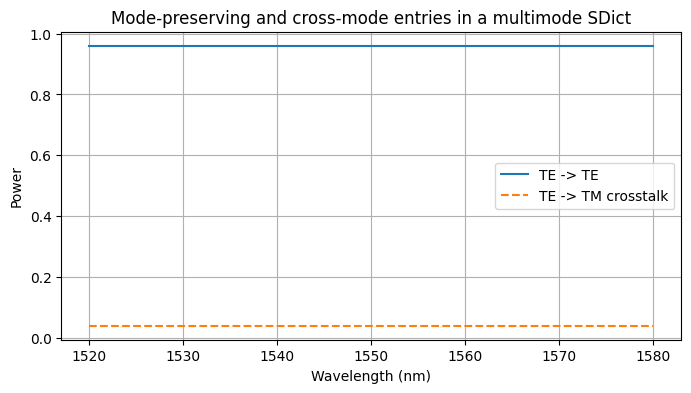

In [5]:
def y_branch_mm(wl=1.55):
    models_by_mode = {
        'te': partial(y_branch, pol='te'),
        'tm': partial(y_branch, pol='tm'),
    }
    return create_multimode_sax_model(models_by_mode)(wl=wl)


def add_output_mode_crosstalk(sdict, xt_power=0.08):
    mixed = dict(sdict)
    stay = jnp.sqrt(1.0 - xt_power)
    cross = 1j * jnp.sqrt(xt_power)

    for (src, dst), value in list(sdict.items()):
        if '@' not in src or '@' not in dst:
            continue
        src_port, src_mode = src.split('@')
        dst_port, dst_mode = dst.split('@')
        if src_mode != dst_mode:
            continue

        other_mode = 'tm' if dst_mode == 'te' else 'te'
        mixed[(src, dst)] = stay * value
        mixed[(src, f'{dst_port}@{other_mode}')] = cross * value

    return mixed


def y_branch_mm_with_crosstalk(wl=1.55, xt_power=0.08):
    return add_output_mode_crosstalk(y_branch_mm(wl=wl), xt_power=xt_power)


def waveguide_mm(wl=1.55, length=10.0, width=500.0, height=220.0, loss=0.0):
    models_by_mode = {
        'te': partial(waveguide, pol='te'),
        'tm': partial(waveguide, pol='tm'),
    }
    return create_multimode_sax_model(models_by_mode)(
        wl=wl,
        length=length,
        width=width,
        height=height,
        loss=loss,
    )


def waveguide_mm_with_crosstalk(wl=1.55, length=10.0, xt_power=0.12, **kwargs):
    sdict = dict(waveguide_mm(wl=wl, length=length, **kwargs))
    stay = jnp.sqrt(1.0 - xt_power)
    cross = 1j * jnp.sqrt(xt_power)

    te_forward = sdict[('o0@te', 'o1@te')]
    tm_forward = sdict[('o0@tm', 'o1@tm')]
    te_backward = sdict[('o1@te', 'o0@te')]
    tm_backward = sdict[('o1@tm', 'o0@tm')]

    sdict[('o0@te', 'o1@te')] = stay * te_forward
    sdict[('o0@tm', 'o1@tm')] = stay * tm_forward
    sdict[('o1@te', 'o0@te')] = stay * te_backward
    sdict[('o1@tm', 'o0@tm')] = stay * tm_backward

    sdict[('o0@te', 'o1@tm')] = cross * te_forward
    sdict[('o0@tm', 'o1@te')] = cross * tm_forward
    sdict[('o1@te', 'o0@tm')] = cross * te_backward
    sdict[('o1@tm', 'o0@te')] = cross * tm_backward
    return sdict


wavelengths_um = np.linspace(1.52, 1.58, 200)
example_sdict = waveguide_mm_with_crosstalk(wl=wavelengths_um, length=50.0, xt_power=0.04)

print('first multimode waveguide keys:')
for key in list(example_sdict.keys())[:10]:
    print(' ', key)

plt.figure(figsize=(8, 4))
plt.plot(wavelengths_um * 1e3, np.abs(example_sdict[('o0@te', 'o1@te')]) ** 2, label='TE -> TE')
plt.plot(wavelengths_um * 1e3, np.abs(example_sdict[('o0@te', 'o1@tm')]) ** 2, '--', label='TE -> TM crosstalk')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Power')
plt.title('Mode-preserving and cross-mode entries in a multimode SDict')
plt.grid(True)
plt.legend()
plt.show()

## 6. Build the 16-QAM MZI/IQ Lattice

The transmitter is an MZI lattice rather than a single component. It uses the same split-phase-recombine idea as the MZI lattice tutorial, but now the optical signals carry both TE and TM modes.

The signal path is:

```text
laser
  -> y1
      -> y2 -> two I arms -> y4
      -> y3 -> two Q arms -> y5 -> pi/2 bias
  -> y6 -> out
```

Block mode treats the `connections` dictionary as directed signal flow. Each entry is written as:

```python
'upstream_instance,upstream_port': 'downstream_instance,downstream_port'
```

If an S-parameter component does not receive explicit `port_directionality`, the circuit builder infers the directions from that directed netlist form: ports that appear on the left-hand side of `connections` are treated as outputs, ports that appear only on the right-hand side are treated as inputs, and unconnected S-parameter ports default to outputs.

That inference is useful for simple directed circuits. In this example we still set `port_directionality` explicitly later because the same `y_branch` SAX model is used as both a splitter and a combiner, so the intended input/output roles flip depending on where the instance sits in the lattice.

The `I` and `Q` branches each use a pair of opposite phase modulators. That makes each branch act like a small interferometric amplitude modulator before the final recombination.

In [6]:
qam_netlist = {
    'instances': {
        'laser': 'laser',
        'wg1': 'waveguide',
        'wg2': 'waveguide',
        'wg3': 'waveguide',
        'wg4': 'waveguide',
        'y1': 'y_branch',
        'y2': 'y_branch',
        'y3': 'y_branch',
        'y4': 'y_branch',
        'y5': 'y_branch',
        'y6': 'y_branch',
        'pm1': 'phase_modulator1',
        'pm2': 'phase_modulator2',
        'pm3': 'phase_modulator3',
        'pm4': 'phase_modulator4',
        'pm5': 'phase_modulator5',
        'pm6': 'phase_modulator6',
    },
    'connections': {
        'laser,o0': 'y1,port_1',
        'y1,port_2': 'y2,port_1',
        'y1,port_3': 'y3,port_1',
        'wg1,o0': 'y2,port_2',
        'wg2,o0': 'y2,port_3',
        'wg3,o0': 'y3,port_2',
        'wg4,o0': 'y3,port_3',
        'wg1,o1': 'pm1,o0',
        'wg2,o1': 'pm2,o0',
        'wg3,o1': 'pm3,o0',
        'wg4,o1': 'pm4,o0',
        'y4,port_2': 'pm1,o1',
        'y4,port_3': 'pm2,o1',
        'y5,port_2': 'pm3,o1',
        'y5,port_3': 'pm4,o1',
        'y5,port_1': 'pm5,o0',
        'pm5,o1': 'y6,port_2',
        'y4,port_1': 'y6,port_3',
        'y6,port_1': 'pm6,o0',
    },
    'ports': {
        'o1': 'pm6,o1',
    },
}

print('instances:', len(qam_netlist['instances']))
print('connections:', len(qam_netlist['connections']))
print('top-level ports:', qam_netlist['ports'])

instances: 17
connections: 19
top-level ports: {'o1': 'pm6,o1'}


## 7. Configure Models and Settings

The same `y_branch` model is used as both a splitter and a combiner. The instance settings tell Block mode which physical ports are inputs and outputs for each use.

For S-parameter components, each setting can include three important pieces:

- `sax_settings`: parameters passed to the SAX model.
- `port_directionality`: the directed role of each physical port in Block mode.
- `vector_fitting_parameters`: how the wavelength-domain S-parameters are converted into time-domain state-space filters.

Important caveat: if a setting entry includes `port_directionality` or `vector_fitting_parameters`, it must also include `sax_settings`. If the SAX model does not need any parameters, use an empty dictionary: `sax_settings: {}`. That keeps simulator metadata separate from the kwargs that are passed into the SAX model.

The MZI tutorial already explains vector fitting in detail; here the point is that the same settings pattern works for multimode S-parameter components.

In [7]:
ARM_LENGTH_UM = 30.0

SPLITTER_DIRECTIONALITY = {'port_1': 'input', 'port_2': 'output', 'port_3': 'output'}
COMBINER_DIRECTIONALITY = {'port_1': 'output', 'port_2': 'input', 'port_3': 'input'}
WAVEGUIDE_DIRECTIONALITY = {'o0': 'input', 'o1': 'output'}


def build_models(waveguide_model, y_branch_model=y_branch_mm):
    return {
        'waveguide': waveguide_model,
        'y_branch': y_branch_model,
        'phase_modulator1': OpticalModulatorTime,
        'phase_modulator2': OpticalModulatorTime,
        'phase_modulator3': OpticalModulatorTime,
        'phase_modulator4': OpticalModulatorTime,
        'phase_modulator5': OpticalModulatorTime,
        'phase_modulator6': OpticalModulatorTime,
        'laser': MultiModeCWLaser,
    }


def build_settings():
    return {
        'laser': {},
        'pm1': {'mod_signal': phase_wave1},
        'pm2': {'mod_signal': phase_wave2},
        'pm3': {'mod_signal': phase_wave3},
        'pm4': {'mod_signal': phase_wave4},
        'pm5': {'mod_signal': jnp.pi / 2 * jnp.ones_like(t)},
        'wg1': {
            'sax_settings': {'length': 30.0},
            'port_directionality': {'o0': 'input', 'o1': 'output'},
        },
        'wg2': {
            'sax_settings': {'length': 30.0},
            'port_directionality': {'o0': 'input', 'o1': 'output'},
        },
        'wg3': {
            'sax_settings': {'length': 30.0},
            'port_directionality': {'o0': 'input', 'o1': 'output'},
        },
        'wg4': {
            'sax_settings': {'length': 30.0},
            'port_directionality': {'o0': 'input', 'o1': 'output'},
        },
        'y1': {
            'sax_settings': {},
            'port_directionality': {'port_1': 'input', 'port_2': 'output', 'port_3': 'output'},
        },
        'y2': {
            'sax_settings': {},
            'port_directionality': {'port_1': 'input', 'port_2': 'output', 'port_3': 'output'},
        },
        'y3': {
            'sax_settings': {},
            'port_directionality': {'port_1': 'input', 'port_2': 'output', 'port_3': 'output'},
        },
        'y4': {
            'sax_settings': {},
            'port_directionality': {'port_1': 'output', 'port_2': 'input', 'port_3': 'input'},
        },
        'y5': {
            'sax_settings': {},
            'port_directionality': {'port_1': 'output', 'port_2': 'input', 'port_3': 'input'},
        },
        'y6': {
            'sax_settings': {},
            'port_directionality': {'port_1': 'output', 'port_2': 'input', 'port_3': 'input'},
        },
    }


settings = build_settings()
models = build_models(waveguide_mm)
print('settings entries:', len(settings))

settings entries: 16


## 8. Run No-Cross-Pol and Cross-Pol Simulations

We run the same MZI/IQ lattice twice:

1. `waveguide_mm`: TE and TM propagate independently.
2. `waveguide_mm_with_crosstalk`: waveguides include off-diagonal mode terms such as `('o0@te', 'o1@tm')`.

The circuit topology and modulation waveforms are identical. Only the waveguide SAX model changes.

In [8]:
simulation_parameters = BlockModeSimulationParameters(
    mode_identifiers=MODE_IDENTIFIERS,
    dt=DT,
    num_time_steps=Nsteps,
    optical_baseband_wavelengths=BASEBAND_WAVELENGTHS_M,
    use_speed_up=True,
)


def run_qam_simulation(waveguide_model, y_branch_model=y_branch_mm):
    circuit = Circuit(qam_netlist, build_models(waveguide_model, y_branch_model))
    simulation = BlockModeSimulation(
        circuit,
        settings=build_settings(),
        simulation_parameters=simulation_parameters,
    )
    result = simulation.run()
    output_signal = result.output_signals['o1']
    output_fields = np.asarray(output_signal.amplitude[:, 0, :])
    return result, output_signal, output_fields


result_no_cross, output_no_cross, fields_no_cross = run_qam_simulation(waveguide_mm)
result_cross, output_cross, fields_cross = run_qam_simulation(waveguide_mm_with_crosstalk, y_branch_mm_with_crosstalk)

print('no-cross-pol output shape:', output_no_cross.amplitude.shape)
print('cross-pol output shape:', output_cross.amplitude.shape)
print('wavelength grid (nm):', np.asarray(output_no_cross.wavelength) * 1e9)
print('mode order:', MODE_IDENTIFIERS)

no-cross-pol output shape: (500000, 1, 2)
cross-pol output shape: (500000, 1, 2)
wavelength grid (nm): [1550.]
mode order: ('te', 'tm')


## 9. Build the Same Constellation Diagrams as the Source Notebook

Output is plotted and upsampled for easier viewing following the steps below:

1. Extract TE and TM complex fields.
2. Build `I` and `Q` arrays from the real and imaginary parts.
3. Upsample the I/Q trajectory so transitions between constellation points are visible.


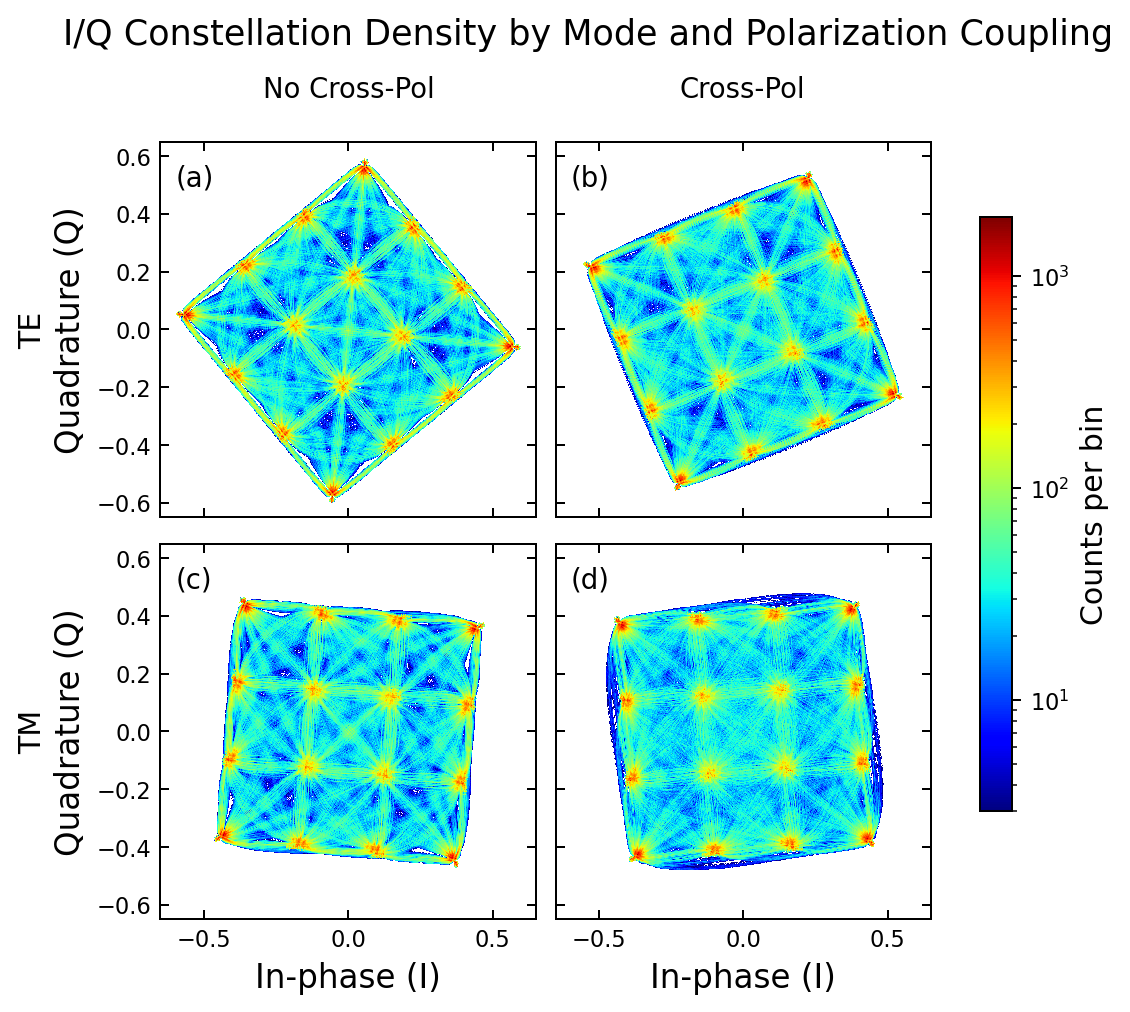

In [12]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


def upsample_trajectory(I, Q, factor=20):
    I = np.asarray(I)
    Q = np.asarray(Q)

    alpha = np.arange(factor, dtype=np.float64) / factor
    I_seg = I[:-1, None] + (I[1:] - I[:-1])[:, None] * alpha
    Q_seg = Q[:-1, None] + (Q[1:] - Q[:-1])[:, None] * alpha

    I_out = np.empty((len(I) - 1) * factor + 1, dtype=I_seg.dtype)
    Q_out = np.empty((len(Q) - 1) * factor + 1, dtype=Q_seg.dtype)

    I_out[:-1] = I_seg.reshape(-1)
    Q_out[:-1] = Q_seg.reshape(-1)
    I_out[-1] = I[-1]
    Q_out[-1] = Q[-1]

    return I_out, Q_out


def center_and_scale(field, skip_symbols=8, target_radius=0.58):
    start = skip_symbols * SAMPLES_PER_SYMBOL
    field = np.asarray(field[start:])
    field = field - np.mean(field)
    scale = np.percentile(np.abs(field), 99)
    return target_radius * field / scale

y = center_and_scale(fields_no_cross[:, mode_index['te']])
I = y.real
Q = y.imag

ym = center_and_scale(fields_no_cross[:, mode_index['tm']])
Im = ym.real
Qm = ym.imag

y_cross_talk = center_and_scale(fields_cross[:, mode_index['te']])
I_cross_talk = y_cross_talk.real
Q_cross_talk = y_cross_talk.imag

ym_cross_talk = center_and_scale(fields_cross[:, mode_index['tm']])
Im_cross_talk = ym_cross_talk.real
Qm_cross_talk = ym_cross_talk.imag

# Composite version of the standalone hist2d plots above.
# Uses raw counts with one global color scale anchored to the reference panel.
plot_inputs = {
    ('TE', 'No Cross-Pol'): (I, Q),
    ('TE', 'Cross-Pol'): (I_cross_talk, Q_cross_talk),
    ('TM', 'No Cross-Pol'): (Im, Qm),
    ('TM', 'Cross-Pol'): (Im_cross_talk, Qm_cross_talk),
}

rows = ['TE', 'TM']
cols = ['No Cross-Pol', 'Cross-Pol']
panel_labels = ['(a)', '(b)', '(c)', '(d)']
upsample_factor = 30
bins = 800
axis_limit = 0.65
min_count = 3
reference_panel = ('TE', 'No Cross-Pol')

plot_data = {
    key: upsample_trajectory(i_vals, q_vals, factor=upsample_factor)
    for key, (i_vals, q_vals) in plot_inputs.items()
}

if axis_limit is None:
    all_iq = np.concatenate([np.r_[i_vals, q_vals] for i_vals, q_vals in plot_data.values()])
    axis_limit = np.ceil(np.nanmax(np.abs(all_iq)) * 1.05 * 20) / 20

plot_range = [[-axis_limit, axis_limit], [-axis_limit, axis_limit]]
panel_maxes = {}
for key, (i_vals, q_vals) in plot_data.items():
    hist, _, _ = np.histogram2d(i_vals, q_vals, bins=bins, range=plot_range)
    panel_maxes[key] = hist.max()

reference_max = max(min_count, panel_maxes[reference_panel])
color_norm = matplotlib.colors.LogNorm(vmin=min_count, vmax=reference_max)
colorbar_extend = 'max' if max(panel_maxes.values()) > reference_max else 'neither'

with plt.rc_context({
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 13,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.titlesize': 13,
    'figure.dpi': 180,
    'savefig.dpi': 600,
}):
    fig, axes = plt.subplots(2, 2, figsize=(6.7, 6.0), sharex=True, sharey=True)
    fig.subplots_adjust(left=0.145, right=0.785, bottom=0.12, top=0.84, wspace=0.05, hspace=0.07)
    images = []

    for row_idx, mode in enumerate(rows):
        for col_idx, coupling in enumerate(cols):
            ax = axes[row_idx, col_idx]
            i_plot, q_plot = plot_data[(mode, coupling)]

            _, _, _, image = ax.hist2d(
                i_plot,
                q_plot,
                bins=bins,
                range=plot_range,
                cmap='jet',
                norm=color_norm,
                cmin=min_count,
                linewidths=0,
                antialiased=False,
            )
            image.set_rasterized(True)
            images.append(image)

            ax.set_aspect('equal', adjustable='box')
            if axis_limit is not None:
                ax.set_xlim(-axis_limit, axis_limit)
                ax.set_ylim(-axis_limit, axis_limit)
            ax.tick_params(direction='in', top=True, right=True)
            ax.text(
                0.04,
                0.94,
                panel_labels[row_idx * 2 + col_idx],
                transform=ax.transAxes,
                ha='left',
                va='top',
                fontsize=11,
                color='black',
                bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.75, 'pad': 1.5},
            )

            if row_idx == 1:
                ax.set_xlabel('In-phase (I)')
            if col_idx == 0:
                ax.set_ylabel('Quadrature (Q)')
                ax.annotate(
                    mode,
                    xy=(-0.34, 0.5),
                    xycoords='axes fraction',
                    ha='center',
                    va='center',
                    rotation=90,
                    fontsize=12,
                )

    fig.text(0.302, 0.875, 'No Cross-Pol', ha='center', va='bottom', fontsize=11)
    fig.text(0.628, 0.875, 'Cross-Pol', ha='center', va='bottom', fontsize=11)
    fig.suptitle('I/Q Constellation Density by Mode and Polarization Coupling', y=0.955, fontsize=14)
    cbar_ax = fig.add_axes([0.825, 0.22, 0.027, 0.55])
    cbar = fig.colorbar(images[0], cax=cbar_ax, extend=colorbar_extend)
    cbar.set_label('Counts per bin', fontsize=12)
    cbar.ax.tick_params(labelsize=9)

    plt.show()


Here we see the TE and TM panels are rotated differently due to a difference in the effective index leading to different global phase shifts

When we enable cross-polarization, the off-diagonal multimode S-parameter terms mix energy between TE and TM. That makes the constellations less clean because each mode now contains a small contribution that followed the other mode's phase evolution.